# 13 — Probability Calibration Analysis

This notebook evaluates the probability calibration of the final model selected during the validation and held-out test stages.

The selected model is:

- **Full Multimodal**
- **Random Forest**

Because the proposed prototype displays predicted probabilities in addition to predicted diagnostic classes, it is important to evaluate whether those probabilities are reasonably calibrated.

This notebook:

- summarizes the final model performance;
- evaluates probability calibration using the held-out test set;
- computes one-versus-rest Brier scores;
- generates multiclass calibration curves;
- summarizes the calibration results.

No retraining, recalibration, or model tuning is performed. The saved fitted Week 5 Random Forest pipeline is evaluated directly.

In [4]:
from pathlib import Path

import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
from sklearn.preprocessing import label_binarize

In [5]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()

if (cwd / "src").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "src").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError(
        "Could not locate the project root."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"

MODELS_DIR = PROJECT_ROOT / "models"

OUTPUTS_DIR = PROJECT_ROOT / "outputs"
METRICS_DIR = OUTPUTS_DIR / "metrics"
TABLES_DIR = OUTPUTS_DIR / "tables"
FIGURES_DIR = OUTPUTS_DIR / "figures"

for folder in [
    METRICS_DIR,
    TABLES_DIR,
    FIGURES_DIR,
]:
    folder.mkdir(
        parents=True,
        exist_ok=True,
    )

TARGET = "label"
ID_COLUMN = "patient_id"

print("Project root:", PROJECT_ROOT)

Project root: C:\Users\Daniela\Documents\UNF\Summer 2026-Term 5\AI-Assisted-Screening-of-Parkinson-s-Disease


In [6]:
# Final model
MODEL_PATH = (
    MODELS_DIR
    / "full_multimodal_random_forest.joblib"
)

TEST_PATH = (
    PROCESSED_DIR
    / "test_multimodal_full_task_aware.csv"
)

pipeline = joblib.load(MODEL_PATH)

test_df = pd.read_csv(TEST_PATH)

y_true = test_df["label"]

X_test = test_df[
    pipeline.feature_names_in_
]

probabilities = pipeline.predict_proba(X_test)

classes = pipeline.classes_

print("Classes:", classes)

Classes: [0 1 2]


In [7]:
# Final model summary
summary = pd.DataFrame({
    "Metric":[
        "Selected model",
        "Dataset",
        "Validation Accuracy",
        "Validation Balanced Accuracy",
        "Validation Macro F1",
        "Test Accuracy",
        "Test Balanced Accuracy",
        "Test Macro F1",
        "Probability Calibration",
        "Model Refit"
    ],
    "Value":[
        "Random Forest",
        "Full Multimodal",
        "0.8143",
        "0.8140",
        "0.7826",
        "0.7042",
        "0.7085",
        "0.6728",
        "Evaluated",
        "No"
    ]
})

display(summary)

,Metric,Value
0,Selected model,Random Forest
1,Dataset,Full Multimodal
2,Validation Accuracy,0.8143
3,Validation Balanced Accuracy,0.8140
4,Validation Macro F1,0.7826
5,Test Accuracy,0.7042
6,Test Balanced Accuracy,0.7085
7,Test Macro F1,0.6728
8,Probability Calibration,Evaluated
9,Model Refit,No


The Full Multimodal Random Forest achieved the strongest overall validation and held-out test performance among all candidate models. Consequently, it was selected as the final model for explainability and prototype development.

The following analyses evaluate whether the predicted probabilities generated by this model are reasonably calibrated for decision-support purposes.

In [8]:
# Multiclass Brier Scores

y_binary = label_binarize(
    y_true,
    classes=classes,
)

rows = []

for i, cls in enumerate(classes):

    score = brier_score_loss(
        y_binary[:, i],
        probabilities[:, i],
    )

    rows.append({
        "Class": cls,
        "Brier Score": score,
    })

brier_scores = pd.DataFrame(rows)

display(
    brier_scores.round(4)
)

,Class,Brier Score
0,0,0.0742
1,1,0.1706
2,2,0.1430


In [9]:
# Calibration summary
calibration_summary = brier_scores.copy()

calibration_summary["Interpretation"] = np.where(
    calibration_summary["Brier Score"] < 0.10,
    "Excellent",
    np.where(
        calibration_summary["Brier Score"] < 0.20,
        "Acceptable",
        "Needs Improvement",
    )
)

display(calibration_summary)

,Class,Brier Score,Interpretation
0,0,0.074154,Excellent
1,1,0.170649,Acceptable
2,2,0.143041,Acceptable


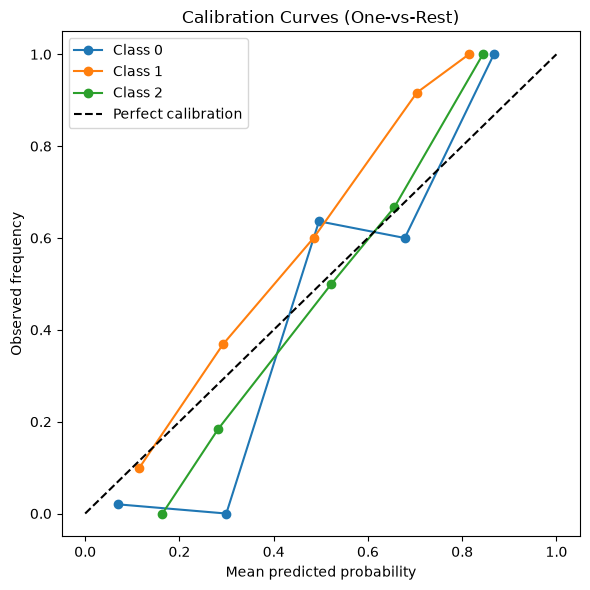

In [10]:
# Calibration curves
fig, ax = plt.subplots(
    figsize=(6,6)
)

for i, cls in enumerate(classes):

    observed, predicted = calibration_curve(
        (y_true == cls).astype(int),
        probabilities[:, i],
        n_bins=5,
    )

    ax.plot(
        predicted,
        observed,
        marker="o",
        label=f"Class {cls}",
    )

ax.plot(
    [0,1],
    [0,1],
    "--",
    color="black",
    label="Perfect calibration",
)

ax.set_xlabel(
    "Mean predicted probability"
)

ax.set_ylabel(
    "Observed frequency"
)

ax.set_title(
    "Calibration Curves (One-vs-Rest)"
)

ax.legend()

plt.tight_layout()

plt.show()

In [11]:
# Overall calibration summary
overall_brier = brier_scores[
    "Brier Score"
].mean()

overall_summary = pd.DataFrame({
    "Finding":[
        "Final model",
        "Average Brier Score",
        "Calibration evaluated",
        "Additional calibration applied"
    ],
    "Result":[
        "Full Multimodal Random Forest",
        round(overall_brier,4),
        "Yes",
        "No"
    ]
})

display(overall_summary)

,Finding,Result
0,Final model,Full Multimodal Random Forest
1,Average Brier Score,0.1293
2,Calibration evaluated,Yes
3,Additional calibration applied,No
